https://www.kaggle.com/datasets/zhangluyuan/ab-testing

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('ab_data.csv')

print(df.head())

print(df.info())

   user_id                   timestamp      group landing_page  converted
0   851104  2017-01-21 22:11:48.556739    control     old_page          0
1   804228  2017-01-12 08:01:45.159739    control     old_page          0
2   661590  2017-01-11 16:55:06.154213  treatment     new_page          0
3   853541  2017-01-08 18:28:03.143765  treatment     new_page          0
4   864975  2017-01-21 01:52:26.210827    control     old_page          1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB
None


In [2]:
print("Nombre total de lignes :", len(df))
print(df['group'].value_counts())
print(pd.crosstab(df['group'], df['landing_page']))

Nombre total de lignes : 294478
group
treatment    147276
control      147202
Name: count, dtype: int64
landing_page  new_page  old_page
group                           
control           1928    145274
treatment       145311      1965


In [5]:
df_cleaned = df[
    ((df['group'] == 'control') & (df['landing_page'] == 'old_page')) |
    ((df['group'] == 'treatment') & (df['landing_page'] == 'new_page'))
]

print("taille avant nettoyage :", len(df))
print("taille après nettoyage :", len(df_cleaned))


taille avant nettoyage : 294478
taille après nettoyage : 290585


In [8]:
conversion_rates = df_cleaned.groupby('group')['converted'].mean()
print(conversion_rates)

group
control      0.120386
treatment    0.118807
Name: converted, dtype: float64


In [9]:
import statsmodels.api as sm

conversions = df_cleaned.groupby('group')['converted'].sum()
nobs = df_cleaned.groupby('group')['converted'].count()

print("Conversions :")
print(conversions)
print("\nTotaux par groupe :")
print(nobs)

z_score, p_value = sm.stats.proportions_ztest(conversions, nobs)

print(f"\nZ-score : {z_score:.4f}")
print(f"P-value : {p_value:.4f}")

Conversions :
group
control      17489
treatment    17264
Name: converted, dtype: int64

Totaux par groupe :
group
control      145274
treatment    145311
Name: converted, dtype: int64

Z-score : 1.3116
P-value : 0.1897


/tmp/ipykernel_1879/2068620023.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=rates.index, y=rates.values, palette=['#e74c3c', '#3498db'])


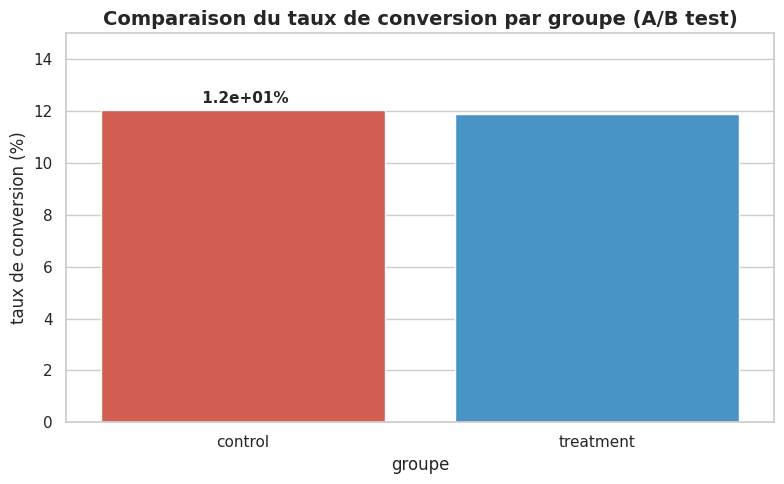

<Figure size 640x480 with 0 Axes>

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8,5))

rates = conversion_rates * 100

ax = sns.barplot(x=rates.index, y=rates.values, palette=['#e74c3c', '#3498db'])

plt.title('Comparaison du taux de conversion par groupe (A/B test)', fontsize=14, fontweight='bold')
plt.xlabel('groupe', fontsize=12)
plt.ylabel('taux de conversion (%)', fontsize=12)
plt.ylim(0, 15)

for p in ax.patches:
  height = p.get_height()
  ax.annotate(f'{height: .2}%',
              (p.get_x() + p.get_width() / 2., height),
              ha='center', va='bottom', fontsize=11, fontweight='bold',
              xytext=(0, 3), textcoords='offset points')
  plt.tight_layout()
  plt.show()

L'analyse de l'A/B test montre un taux de conversion de 12,04% pour l'ancienne page contre 11,88% pour la nouvelle page. Le Z-test des proportions a révélé une p-value de 0.1897 (supérieure au seuil de signification de 0.05). Par conséquent, la différence observée n'est pas statistiquement significative. Recommandation : Ne pas déployer la nouvelle page en production et capitaliser sur d'autres axes d'optimisation ou concevoir une version alternative plus performante.